In [14]:
import time
import matplotlib.pyplot as plt
from auxillary.helper import create_random_graph, print_graph
from auxillary.helper import Graph
from approximation_implementations import *
from math import floor
from collections import Counter
import numpy as np

Edges:  1 | A1 Error: 1.000 | A2 Error: 3.684 | A3 Error: 2.000
Edges:  2 | A1 Error: 1.000 | A2 Error: 3.033 | A3 Error: 2.000
Edges:  3 | A1 Error: 1.000 | A2 Error: 2.650 | A3 Error: 1.947
Edges:  4 | A1 Error: 1.013 | A2 Error: 2.374 | A3 Error: 1.919
Edges:  5 | A1 Error: 1.015 | A2 Error: 2.200 | A3 Error: 1.880
Edges:  6 | A1 Error: 1.017 | A2 Error: 2.094 | A3 Error: 1.842
Edges:  7 | A1 Error: 1.022 | A2 Error: 1.966 | A3 Error: 1.805
Edges:  8 | A1 Error: 1.023 | A2 Error: 1.864 | A3 Error: 1.771
Edges:  9 | A1 Error: 1.027 | A2 Error: 1.821 | A3 Error: 1.747
Edges: 10 | A1 Error: 1.021 | A2 Error: 1.736 | A3 Error: 1.697
Edges: 11 | A1 Error: 1.023 | A2 Error: 1.705 | A3 Error: 1.689
Edges: 12 | A1 Error: 1.027 | A2 Error: 1.651 | A3 Error: 1.654
Edges: 13 | A1 Error: 1.025 | A2 Error: 1.608 | A3 Error: 1.615
Edges: 14 | A1 Error: 1.030 | A2 Error: 1.577 | A3 Error: 1.608
Edges: 15 | A1 Error: 1.027 | A2 Error: 1.548 | A3 Error: 1.579
Edges: 16 | A1 Error: 1.027 | A2 Error: 

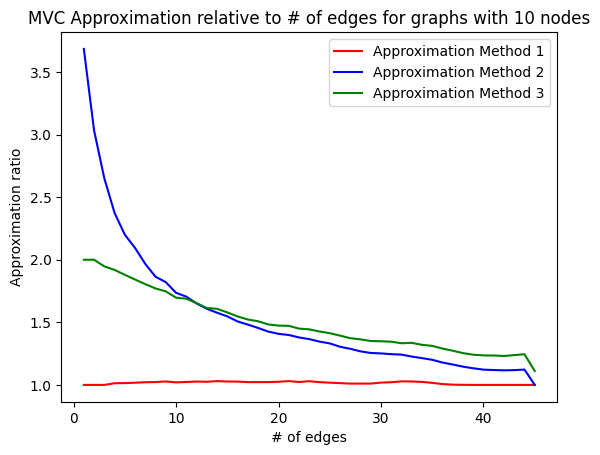

In [169]:
# experiment 1
actual_MVCs, approx1_MVCs, approx2_MVCs, approx3_MVCs = 0, 0, 0, 0
# edges = [1, 5, 10, 15, 20, 25, 30, 35, 40, 45]
trials = 1000
nodes = 10

ratio1, ratio2, ratio3 = [], [], []

# checking edges 1-45 1 step
for m in range(1,46):
    actual_MVCs, approx1_MVCs, approx2_MVCs, approx3_MVCs = 0, 0, 0, 0
    for _ in range(trials):
        G = create_random_graph(nodes, m)
        actual_MVCs += len(MVC(G))
        approx1_MVCs += len(approx1(G))
        approx2_MVCs += len(approx2(G))
        approx3_MVCs += len(approx3(G))
    current_ratio_a1 = approx1_MVCs / actual_MVCs
    current_ratio_a2 = approx2_MVCs / actual_MVCs
    current_ratio_a3 = approx3_MVCs / actual_MVCs

    ratio1.append(current_ratio_a1)
    ratio2.append(current_ratio_a2)
    ratio3.append(current_ratio_a3)

    print(f"Edges: {m:2} | A1 Error: {current_ratio_a1:.3f} | A2 Error: {current_ratio_a2:.3f} | A3 Error: {current_ratio_a3:.3f}")
plt.plot([_ for _ in range(1,46)], ratio1, color='red')
plt.plot([_ for _ in range(1,46)], ratio2, color='blue')
plt.plot([_ for _ in range(1,46)], ratio3, color='green')
plt.legend(['Approximation Method 1', 'Approximation Method 2', 'Approximation Method 3'])
plt.xlabel('# of edges')
plt.ylabel('Approximation ratio')
plt.title('MVC Approximation relative to # of edges for graphs with 10 nodes')
plt.show()

Notes on the first experiment: Here, we are testing the performance of the 3 approximations on a graph with 10 nodes, where the number of edges varies from 1 - 45. In other words, we are comparing performance on a completely sparse graph (single edge), all the way up to a graph with the maximum density (i.e., every node connects to every other, for 10 nodes this is edges = 45). This already gives insight into the behaviour of the algorithms that makes sense. 

Edges:  2 | A1 Error: 1.000 | A2 Error: 1.785 | A3 Error: 2.000
Edges:  4 | A1 Error: 1.042 | A2 Error: 1.613 | A3 Error: 1.769
Edges:  6 | A1 Error: 1.002 | A2 Error: 1.517 | A3 Error: 1.645
Edges:  8 | A1 Error: 1.026 | A2 Error: 1.550 | A3 Error: 1.640
Edges: 11 | A1 Error: 1.030 | A2 Error: 1.519 | A3 Error: 1.596
Edges: 14 | A1 Error: 1.022 | A2 Error: 1.501 | A3 Error: 1.548
Edges: 18 | A1 Error: 1.024 | A2 Error: 1.468 | A3 Error: 1.524
Edges: 22 | A1 Error: 1.024 | A2 Error: 1.441 | A3 Error: 1.480
Edges: 26 | A1 Error: 1.030 | A2 Error: 1.437 | A3 Error: 1.476
Edges: 31 | A1 Error: 1.029 | A2 Error: 1.412 | A3 Error: 1.441


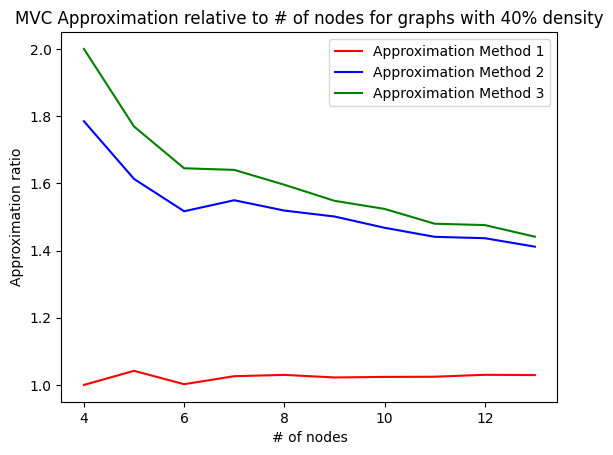

In [39]:
# experiment 2
trials = 1000

ratio1, ratio2, ratio3 = [], [], []

# check from 4 - 13 nodes (min 4 since any less would be less accurate)
for n in range(4, 14):
    actual_MVCs, approx1_MVCs, approx2_MVCs, approx3_MVCs = 0, 0, 0, 0
    # calculate the max edges for the npde, 40% of that is how many edges we add
    m = floor(0.4 * (n * (n - 1) / 2))
    for _ in range(trials):
        G = create_random_graph(n, m)
        actual_MVCs += len(MVC(G))
        approx1_MVCs += len(approx1(G))
        approx2_MVCs += len(approx2(G))
        approx3_MVCs += len(approx3(G))
    current_ratio_a1 = approx1_MVCs / actual_MVCs
    current_ratio_a2 = approx2_MVCs / actual_MVCs
    current_ratio_a3 = approx3_MVCs / actual_MVCs

    ratio1.append(current_ratio_a1)
    ratio2.append(current_ratio_a2)
    ratio3.append(current_ratio_a3)

    print(f"Edges: {m:2} | A1 Error: {current_ratio_a1:.3f} | A2 Error: {current_ratio_a2:.3f} | A3 Error: {current_ratio_a3:.3f}")
plt.plot([_ for _ in range(4,14)], ratio1, color='red')
plt.plot([_ for _ in range(4,14)], ratio2, color='blue')
plt.plot([_ for _ in range(4,14)], ratio3, color='green')
plt.legend(['Approximation Method 1', 'Approximation Method 2', 'Approximation Method 3'])
plt.xlabel('# of nodes')
plt.ylabel('Approximation ratio')
plt.title('MVC Approximation relative to # of nodes for graphs with 40% density')
plt.show()

Notes on the second experiment: Here, we experiment with the performance as the number of nodes grows (3 - 15 nodes), for a graph with around 50% density. In other words, the relative density of the graph remains the same, but we increase the total number of nodes/edges, and observe the accuracy of the approximations. If we did fix the number of edges and adjust the nodes, we would just be repeating the previous experiment, i.e., checking sparsity.

Worst Ratios -> A1: 1.50 | A2: 4.00 | A3: 2.00
--- Graph Structure (Nodes: 5) ---
  Node 0 -> [4]
  Node 1 -> [3]
  Node 2 -> [3, 4]
  Node 3 -> [1, 2]
  Node 4 -> [0, 2]
--- Graph Structure (Nodes: 5) ---
  Node 0: <isolated>
  Node 1: <isolated>
  Node 2 -> [4]
  Node 3 -> [4]
  Node 4 -> [2, 3]
--- Graph Structure (Nodes: 5) ---
  Node 0: <isolated>
  Node 1: <isolated>
  Node 2: <isolated>
  Node 3 -> [4]
  Node 4 -> [3]


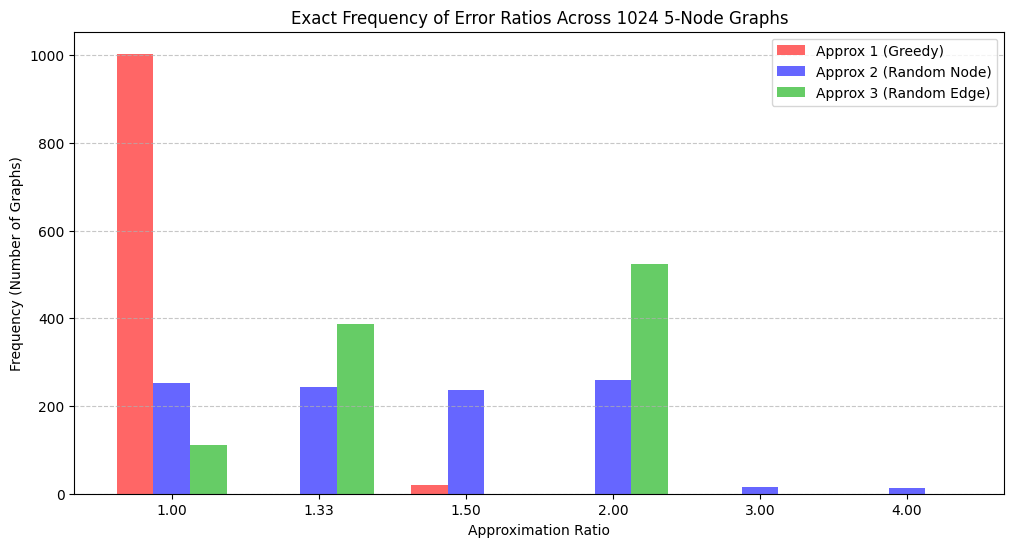

In [42]:
# experiment 3
# generate all graphs of size 5 for worst case scenarios

# first: how many graphs of size 5? If we have 5 nodes, we have the followig possible undirected edges
edges = [(0, 1), (0, 2), (0, 3), (0, 4), (1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]
# thats 10 possible edges. For each edge, we either have it or don't
# i.e., 0 or 1 for 10 digits, or a binary string of length 2^10 = 1024
# So, we will iteratethrough every 1024 string, count in binary
binary_len = len(edges)
graph_size = 5
graphs = []

for i in range(2 ** binary_len):
    binary = bin(i)[2:].zfill(binary_len)
    G = Graph(graph_size)
    for idx, digit in enumerate(binary):
        if digit == '1': G.add_edge(*edges[idx])
    graphs.append(G)

ratios_a1 = []
ratios_a2 = []
ratios_a3 = []

# check each graph, if we hit a worst case, mark it
worst_ratio1, worst_ratio2, worst_ratio3 = 1.0, 1.0, 1.0
worst_graph1, worst_graph2, worst_graph3 = Graph(0), Graph(0), Graph(0)

for g in graphs:
    actual_MVCs = len(MVC(g))
    if actual_MVCs == 0: continue
    current_ratio_a1 = len(approx1(g)) / actual_MVCs
    current_ratio_a2 = len(approx2(g)) / actual_MVCs
    current_ratio_a3 = len(approx3(g)) / actual_MVCs

    ratios_a1.append(current_ratio_a1)
    ratios_a2.append(current_ratio_a2)
    ratios_a3.append(current_ratio_a3)

    if current_ratio_a1 > worst_ratio1:
        worst_ratio1 = current_ratio_a1
        worst_graph1 = g
    if current_ratio_a2 > worst_ratio2:
        worst_ratio2 = current_ratio_a2
        worst_graph2 = g
    if current_ratio_a3 > worst_ratio3:
        worst_ratio3 = current_ratio_a3
        worst_graph3 = g
print(f"Worst Ratios -> A1: {worst_ratio1:.2f} | A2: {worst_ratio2:.2f} | A3: {worst_ratio3:.2f}")


print_graph(worst_graph1)
print_graph(worst_graph2)
print_graph(worst_graph3)

count_a1 = Counter(ratios_a1)
count_a2 = Counter(ratios_a2)
count_a3 = Counter(ratios_a3)

# 2. Find every unique ratio that was generated across all algorithms
# (This will be numbers like 1.0, 1.25, 1.333, 1.5, 2.0, etc.)
all_ratios = sorted(list(set(ratios_a1 + ratios_a2 + ratios_a3)))

# 3. Extract the heights for each ratio (if an algorithm didn't hit it, height is 0)
heights_a1 = [count_a1[r] for r in all_ratios]
heights_a2 = [count_a2[r] for r in all_ratios]
heights_a3 = [count_a3[r] for r in all_ratios]

# 4. Setup the X-axis positions
x = np.arange(len(all_ratios))  # Creates evenly spaced slots: [0, 1, 2, 3...]
width = 0.25                    # How thick the bars should be

# 5. Draw the chart
fig, ax = plt.subplots(figsize=(12, 6))

# We shift the red bars left by 'width', keep blue in the center, and shift green right
ax.bar(x - width, heights_a1, width, color='#ff6666', label='Approx 1 (Greedy)')
ax.bar(x,         heights_a2, width, color='#6666ff', label='Approx 2 (Random Node)')
ax.bar(x + width, heights_a3, width, color='#66cc66', label='Approx 3 (Random Edge)')

# 6. Force the labels to sit EXACTLY under the center of the groups
ax.set_xticks(x)
# Format the labels to 2 decimal places so "1.333333" looks clean
ax.set_xticklabels([f"{r:.2f}" for r in all_ratios])

# 7. Make it professional
ax.set_title('Exact Frequency of Error Ratios Across 1024 5-Node Graphs')
ax.set_xlabel('Approximation Ratio')
ax.set_ylabel('Frequency (Number of Graphs)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()